<h1 style="text-align: center; color: #FFB6C1; font-size: 40px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
    ------- INTRODUÇÃO -------
</h1>


No âmbito da unidade curricular de <font color="#FFB6C1">Aprendizagem Computacionalg I</font>, este trabalho propõe uma exploração aprofundada da a robustez dos algoritmos de aprendizagem supervisionada perante desafios reais de classificação, sendo que o algoritmo central escolhido foi <font color="#FFB6C1">K-Nearest Neighbors (KNN)</font>, assim como o problema de <font color="#FFB6C1">class imbalance</font>.

A escolha do KNN como algoritmo base fundamenta-se na sua natureza geométrica e local, características que o tornam particularmente sensível ao desequilíbrio de classes. Em cenários de Class Imbalance, a classe maioritária tende a dominar o espaço de vizinhança, fazendo com que as amostras da classe minoritária sejam frequentemente classificadas incorretamente como pertencentes à maioria, devido à simples densidade numérica de vizinhos ao redor do ponto de teste. Teoricamente, verifica-se que, em métricas tradicionais, o modelo poderá apresentar uma acurácia ilusoriamente elevada, uma vez que o acerto sistemático na classe dominante mascara o fracasso total na identificação da classe de interesse (minoria) (elevados ). 

Consequentemente, optámos por nos focar em métricas como a <font color="#FFB6C1">precisão, recall e f1-score</font>. A precisão e o recall são essenciais para distinguir entre a exatidão das previsões positivas e a capacidade do modelo em encontrar todos os casos verdadeiros positivos, respetivamente. O F1-score é utilizado como uma média harmónica entre estas duas, oferecendo um equilíbrio necessário quando as classes estão desproporcionais. No entanto, devido à natureza do desequilíbrio, a <font color="#FFB6C1">Balanced Accuracy</font> torna-se a métrica crítica, pois calcula a média aritmética do recall de cada classe, garantindo que o desempenho na classe minoritária tenha o mesmo peso que na maioritária. Complementarmente, as métricas <font color="#FFB6C1">ROC-AUC e PR-AUC </font>(Precision-Recall Area Under Curve) são incluídas para avaliar a capacidade de separação do modelo em diferentes limiares de decisão; a PR-AUC, especificamente, é considerada mais informativa em contextos de Class Imbalance por focar na performance relativa à classe minoritária, evitando o otimismo excessivo que a curva ROC pode apresentar quando a classe negativa é vastamente superior.  


* https://pmc.ncbi.nlm.nih.gov/articles/PMC7206335/#Sec13 (falta ver se usa ou não préprocessamento)



<h1 style="text-align: center; color: #FFB6C1; font-size: 40px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
    ------- IMPORTS -------
</h1>

In [259]:
import numpy as np
from collections import Counter, defaultdict
import pandas as pd
from pandas.api.types import is_numeric_dtype 
import os
import copy
from joblib import Parallel, delayed
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import product
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    recall_score, 
    f1_score, 
    balanced_accuracy_score, 
    roc_auc_score, 
    average_precision_score
)
from sklearn.preprocessing import LabelBinarizer
from sklearn.mixture import GaussianMixture
from scipy.stats import norm
from scipy.spatial.distance import pdist

np.random.seed(42) 

<h1 style="text-align: center; color: #FFB6C1; font-size: 40px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
    ------- MODELOS -------
</h1>

<h1 style="text-align: left; color: #FFB6C1; font-size: 30px; font-family: 'Consolas', 'Courier New', monospace;">
    KNN Base
</h1>

Class base do knn fornecida: para prever a classe de um novo ponto, calcula a distância de todos os pontos do treino ao mesmo, identifica os k vizinhos/pontos mais próximos. A decisão final corresponde à classe com maior frequência dos seus k vizinhos. Para calcular a distância ao novo ponto, utiliza a distância Euclideana: $$d(x, y) = \sqrt{\sum_{i=1}^{n} (x_i - y_i)^2}$$


​

https://github.com/rushter/MLAlgorithms/blob/master/mla/knn.py

In [260]:
class KNNBase:
    def __init__(self, k=3):
        """
        Inicializa o classificador KNN.
        
        Parâmetros:
        k (int): O número de vizinhos a considerar.
        """
        self.k = k

    def fit(self, X, y):
        """
        'Treina' o modelo. No caso do KNN, apenas memorizamos os dados.
        """
        self.X_train = np.array(X)
        self.y_train = np.array(y)

    def predict(self, X):
        """
        Faz a previsão para um conjunto de dados X.
        """
        X = np.array(X)
        # Calcula as previsões iterando sobre cada exemplo de teste
        predictions = [self._predict_single(x) for x in X]
        return np.array(predictions)

    def _predict_single(self, x):
        """
        Lógica interna para prever uma única amostra.
        É aqui que deves mexer se quiseres alterar o coração do algoritmo.
        """
        # 1. Calcular a distância Euclidiana entre 'x' e todos os pontos de treino.
        # Tiramos partido do NumPy (broadcasting) para fazer isto sem loops.
        distancias = np.sqrt(np.sum((self.X_train - x) ** 2, axis=1))

        # 2. Obter os índices dos K vizinhos mais próximos.
        # np.argpartition é mais rápido que np.argsort porque não ordena o array todo,
        # apenas garante que os 'k' menores ficam no início.
        k_indices = np.argpartition(distancias, self.k)[:self.k]

        # 3. Extrair as classes desses K vizinhos
        k_classes_vizinhas = self.y_train[k_indices]

        # 4. Votação por maioria: Qual é a classe mais comum?
        mais_comum = Counter(k_classes_vizinhas).most_common(1)
        
        return mais_comum[0][0]
    
    #Necessário para os outros herdarem esta função
    def predict_proba(self, X):
        """Calcula e retorna as probabilidades da amostra pertencer a cada uma das possíveis classes"""
        X = np.array(X)
        probs = []
        all_classes = np.unique(self.y_train) #identifica as classes (únicas) existentes no conjunto de treino
        for x in X: #percorre cada um dos pontos do conjunto de treino
            #distância euclideana e seleção dos k vizinhos mais próximos
            distancias = np.sqrt(np.sum((self.X_train - x) ** 2, axis=1))
            k_indices = np.argpartition(distancias, self.k)[:self.k]
            k_classes = self.y_train[k_indices]
            # Calcula a probabilidade para cada classe conhecida no treino
            count = Counter(k_classes) #usa o counter para ver quantas vezes cada classe aparece nos k vizinhos mais próximos
            prob_amostra = [count.get(c, 0) / self.k for c in all_classes]
            probs.append(prob_amostra)
        return np.array(probs)



<h1 style="text-align: left; color: #FFB6C1; font-size: 30px; font-family: 'Consolas', 'Courier New', monospace;">
    KNN com distâncias a considerar o peso de cada feature
</h1>

Versão do KNN que, em vez de dar a mesma importância a todos os atributos/features como o KNN tradicional, <font color="#FFB6C1">identifica os atributos mais relevantes, dando-lhes um maior peso na decisão final.</font>
Primeiro, este modelo mede a incerteza dos nossos dados através do cálculo da entropia (1). Depois, para cada atributo calcula o ganho de informação (2). Se um atributo tiver um ganho de informação alto, é muito relevante na separação das classes. Por fim, os ganhos de informação são normalizados e implementados ao calcular a distância ponderada a cada ponto (3).

(1) $$H(y) = -\sum_{j=1}^{C} p_j \log_2(p_j) \quad \text{onde} \quad p_j = \frac{|y_j|}{|y|}$$

(2) $$IG(f) = H(y) - H(y|f) = H(y) - \sum_{b \in \text{bins}} \frac{|y_b|}{|y|} \cdot H(y_b)$$

(3) $$d(x, x_i) = \sqrt{\sum_{j=1}^{M} w_j \cdot (x_j - x_{i,j})^2} \quad \text{com} \quad w_j = \frac{IG(f_j)}{\max(IG)}$$

In [261]:
class KNN_features_weight(KNNBase):
    def __init__(self, k=3, num_bins=10):
        super().__init__(k=k)
        self.num_bins = num_bins
        self.pesos = None

    def _entropia(self, y):
        """Calcula o quão 'caótico' é um conjunto de classes."""
        _, contagens = np.unique(y, return_counts=True)
        probs = contagens / len(y)
        return -np.sum(probs * np.log2(probs))

    def fit(self, X, y):
        super().fit(X, y)
        n_features = self.X_train.shape[1]
        self.pesos = np.zeros(n_features)
        
        # 1. Entropia total do Target (Incerteza inicial)
        h_target = self._entropia(y)

        # 2. Calcular Information Gain para cada feature: IG = H(Target) - H(Target | Feature)
        for i in range(n_features):
            feat = self.X_train[:, i]
            # Divide a feature em 10 intervalos (baldes)
            bins = np.linspace(feat.min(), feat.max(), self.num_bins)
            indices_baldes = np.digitize(feat, bins)
            
            h_condicional = 0
            for b in np.unique(indices_baldes):
                y_no_balde = y[indices_baldes == b]
                peso = len(y_no_balde) / len(y)
                h_condicional += peso * self._entropia(y_no_balde)
            
            # Ganho de informação
            self.pesos[i] = h_target - h_condicional

        # 3. Normalizar pesos (opcional mas ajuda na escala da distância)
        if np.max(self.pesos) > 0:
            self.pesos /= np.max(self.pesos)

    def _predict_single(self, x):
        # Distância Euclidiana Ponderada: simples e direta
        diff_quadrada = (self.X_train - x) ** 2
        distancias = np.sqrt(np.sum(self.pesos * diff_quadrada, axis=1))

        k_indices = np.argpartition(distancias, self.k)[:self.k]
        return Counter(self.y_train[k_indices]).most_common(1)[0][0]


<h1 style="text-align: left; color: #FFB6C1; font-size: 30px; font-family: 'Consolas', 'Courier New', monospace;">
    KNN com class weight
</h1>

Implementação do KNN que <font color="#FFB6C1">atribui pesos a cada classe</font> para obter uma votação ponderada. Calcula o peso de cada classe através do inverso da sua frequência relativa (1). Assim, <font color="#FFB6C1">classes minoritárias têm pesos maiores</font> e classes majoritárias têm pesos menores, combatendo o problema de class imbalance. Por fim, realiza uma votação onde cada voto é multiplicado pelo peso da sua respetiva classe (2).

(1) $$w_c^{\text{class}} = \frac{N_{\text{total}}}{C \cdot N_c}$$

(2) $$\text{score}(c) = \sum_{i \in \mathcal{N}_k(x)} w_{y_i}^{\text{class}} \cdot \mathbb{1}[y_i = c]$$



In [262]:
class KNN_class_weight(KNNBase):
    def __init__(self, k=3):
        super().__init__(k=k)
        self.pesos_classes = {}

    def fit(self, X, y):
        # 1. Guarda os dados de treino usando o método da classe mãe
        super().fit(X, y)
        
        # 2. Conta as ocorrências de cada classe
        classes_unicas, contagens = np.unique(self.y_train, return_counts=True)
        total_amostras = len(self.y_train)
        num_classes = len(classes_unicas)
        
        # 3. Calcula o peso para cada classe (frequência inversa)
        for c, count in zip(classes_unicas, contagens):
            self.pesos_classes[c] = total_amostras / (num_classes * count)
            
        return self

    def _predict_single(self, x):
        # 1. Distância Euclidiana
        distancias = np.sqrt(np.sum((self.X_train - x) ** 2, axis=1))
        
        # 2. Encontra os K vizinhos mais próximos
        k_indices = np.argpartition(distancias, self.k)[:self.k]
        votos = self.y_train[k_indices]
        
        # 3. Votação Ponderada
        contagem_ponderada = defaultdict(float)
        for voto in votos:
            contagem_ponderada[voto] += self.pesos_classes[voto]
            
        # 4. Retorna a classe com a maior soma de pesos
        return max(contagem_ponderada, key=contagem_ponderada.get)


<h1 style="text-align: left; color: #FFB6C1; font-size: 30px; font-family: 'Consolas', 'Courier New', monospace;">
    KNN com class weight e feature weight
</h1>

Implementa uma versão do KNN que combina a ponderação das classes e das features. Inicialmente, calcula as distâncias ponderadas com os pesos dos atributos e depois realiza uma votação onde cada voto é multiplicado pelo respetivo peso da classe.



In [263]:
class KNN_Combined_Weight(KNN_features_weight):
    def __init__(self, k=3, num_bins=10):
        # Herda os atributos da versão de pesos de features
        super().__init__(k=k, num_bins=num_bins)
        self.pesos_classes = {}

    def fit(self, X, y):
        # 1. Executa o cálculo de entropia/pesos das colunas da classe mãe
        super().fit(X, y)
        
        # 2. Calcula os pesos das classes (frequência inversa)
        classes_unicas, contagens = np.unique(self.y_train, return_counts=True)
        total_amostras = len(self.y_train)
        num_classes = len(classes_unicas)
        
        for c, count in zip(classes_unicas, contagens):
            self.pesos_classes[c] = total_amostras / (num_classes * count)
            
        return self

    def _predict_single(self, x):
        # 1. Distância Euclidiana Ponderada pelas Features
        distancias = np.sqrt(np.sum(self.pesos * (self.X_train - x) ** 2, axis=1))
        
        # 2. Encontra os K vizinhos mais próximos
        k_indices = np.argpartition(distancias, self.k)[:self.k]
        votos = self.y_train[k_indices]
        
        # 3. Votação Ponderada pelas Classes O(K)
        contagem_ponderada = defaultdict(float)
        for voto in votos:
            contagem_ponderada[voto] += self.pesos_classes[voto]
            
        # 4. Retorna a classe vencedora
        return max(contagem_ponderada, key=contagem_ponderada.get)


<h1 style="text-align: left; color: #FFB6C1; font-size: 30px; font-family: 'Consolas', 'Courier New', monospace;">
    KNN com RBF Kernel, class e feature weight
</h1>

Variante do KNN que adiciona um Kernel de similaridade Radial Basis Function (RBF) (1), que <font color="#FFB6C1">atribui pesos aos vizinhos mais próximos consoante a sua similaridade à nova amostra</font>, além de implementar os pesos das classes e dos atributos como o anterior.
O algoritmo aplica uma função de similaridade exponencial baseada na distância, sendo que vizinhos mais próximos recebem pesos exponencialmente maiores, enquanto vizinhos nos limites do raio K têm influência reduzida. O parâmetro γ (2) controla a "largura" deste decaimento: valores altos de γ fazem com que apenas vizinhos muito próximos tenham influência significativa.
Esta abordagem cria uma fronteira de decisão mais suave e flexível que o KNN tradicional, atribuindo influência gradual aos vizinhos em vez de um limiar rígido. Isto é particularmente útil quando os dados têm distribuições complexas ou quando existe ruído nas amostras mais distantes.

(1) $$K(x, x_i) = \exp\left(-\gamma \cdot d^2(x, x_i)\right)$$

(2) $$\gamma = \frac{1}{M}$$ se não for fornecido

(3) Votação com Kernel RBF: $$\text{score}(c) = \sum_{i \in \mathcal{N}_k(x)} w_{y_i}^{\text{class}} \cdot \exp\left(-\gamma \cdot d^2(x, x_i)\right) \cdot \mathbb{1}[y_i = c]$$


In [264]:
class KNN_RBF(KNN_Combined_Weight):
    def __init__(self, k=3, num_bins=10, gamma=None):
        super().__init__(k=k, num_bins=num_bins)
        self.gamma = gamma

    def fit(self, X, y):
        super().fit(X, y)
        # Heurística padrão: se gamma não for fornecido, escala consoante o número de features
        if self.gamma is None:
            self.gamma = 1.0 / self.X_train.shape[1]
        return self

    def _predict_single(self, x):
        # 1. Distância ao Quadrado Ponderada pelas Features 
        distancias_sq = np.sum(self.pesos * (self.X_train - x) ** 2, axis=1)
        
        # 2. Encontra os K vizinhos rapidamente
        k_indices = np.argpartition(distancias_sq, self.k)[:self.k]
        votos = self.y_train[k_indices]
        
        # Guardamos as distâncias exatas desses K vizinhos
        distancias_k_sq = distancias_sq[k_indices]
        
        # 3. Calcula a Similaridade RBF APENAS para os K vizinhos (Eficiência máxima)
        similaridades_rbf = np.exp(-self.gamma * distancias_k_sq)
        
        # 4. Votação Ponderada: (Peso da Classe) * (Similaridade RBF)
        contagem_ponderada = defaultdict(float)
        for voto, sim_rbf in zip(votos, similaridades_rbf):
            contagem_ponderada[voto] += self.pesos_classes[voto] * sim_rbf
            
        return max(contagem_ponderada, key=contagem_ponderada.get)


<h1 style="text-align: left; color: #FFB6C1; font-size: 30px; font-family: 'Consolas', 'Courier New', monospace;">
    KNN com Threshold
</h1>

Implementação do KNN que em vez de simplesmente escolher a classe majoritária entre os K vizinhos, calcula a <font color="#FFB6C1">probabilidade da classe minoritária (1) e aplica um limiar/Threshold ajustável</font> para decidir a classificação final. O algoritmo calcula a "probabilidade" da classe minoritária através da proporção da mesma (1) e compára-a com o threshold escolhido. Se a probabilidade for menor que o theshold, prevê a classe majoritária, caso contrário, prevê a classe minoritária. O theshold um valor entre 0 e 1 definido pelo "utilizador", que define o quão "confiante" o algoritmo precisa de estar paraprever a classe majoritária. Quanto maior o threshold, mais exigente é na previsão.

(1) $$P(C_{min}|x) = \frac{1}{k} \sum_{i=1}^{k} I(v_i = C_{min})$$




In [265]:
class KNN_Threshold_Optimizer(KNNBase):
    def __init__(self, k=5, threshold=0.5):
        super().__init__(k=k)
        self.threshold = threshold
        self.min_class = None
        self.maj_class = None

    def fit(self, X, y):
        super().fit(X, y)
        # Identificar classe minoritária e maioritária
        contagens = Counter(self.y_train)
        classes_ordenadas = contagens.most_common()
        self.maj_class = classes_ordenadas[0][0]
        self.min_class = classes_ordenadas[-1][0]
        return self

    def predict_proba(self, X):
        X = np.array(X)
        probabilidades = []
        for x in X:
            distancias = np.sqrt(np.sum((self.X_train - x) ** 2, axis=1))
            k_indices = np.argpartition(distancias, self.k)[:self.k]
            votos = self.y_train[k_indices]
            
            # Fração de votos que pertencem à classe minoritária
            prob_minoria = np.sum(votos == self.min_class) / self.k
            probabilidades.append(prob_minoria)
            
        return np.array(probabilidades)

    def predict(self, X, custom_threshold=None):
        thresh = custom_threshold if custom_threshold is not None else self.threshold
        probs = self.predict_proba(X)
        # Se a probabilidade da minoria for maior que o limiar, prevê minoria
        return np.where(probs >= thresh, self.min_class, self.maj_class)


<h1 style="text-align: left; color: #FFB6C1; font-size: 35px; font-family: 'Consolas', 'Courier New', monospace;">
    CLM-KNN
</h1>

O ClassWise Local Mean KNN (CLM-KNN) é uma versão que, ao contrário do KNN normal, decide a classe com base na frequência dos vizinhos mais próximos, focando-se na proximidade da amostra de teste em relação aos "centros" locais de cada classe. 
Este algoritmo mede a distância entre o ponto de teste e todos os pontos de treino, e para cada classe existente nos dados de treino, identifica apenas os pontos pertencentes a essa classe. A seguir, dentro de cada classe, ele seleciona os k vizinhos mais próximos do ponto de teste e calcula a <font color="#FFB6C1">média aritmética (centroide) desses vizinhos</font>. Por fim, o algoritmo calcula a distância entre o ponto de teste e o centroide local de cada classe, sendo que a classe cujo centroide estiver mais perto do ponto de teste é a classe escolhida. A classe prevista é aquela que minimiza a distância ao seu centroide local.
Uma vez que cada classe tem a oportunidade de apresentar o seu melhor "representante", é uma tática que ajuda a combater o class imbalance.

(1) Distância Euclidiana entre o ponto de teste x e os pontos de treino X_i:
$$d(x, X_i) = \sqrt{\sum_{j=1}^{n} (x_j - X_{i,j})^2}$$

(2) Cálculo do Centroide Local (μ_c) para uma classe c:
$$\mu_c = \frac{1}{k} \sum_{i=1}^{k} v_i$$

(3) Distância ao Centroide Local:
$$D(x, \mu_c) = \sqrt{\sum_{j=1}^{n} (x_j - \mu_{c,j})^2}$$




In [266]:
class KNN_Classwise_Local_Mean(KNNBase):
    def __init__(self, k=3):
        super().__init__(k=k)

    def _predict_single(self, x):
        # 1. Calcular distâncias de x a TODOS os pontos de treino
        distancias = np.sqrt(np.sum((self.X_train - x) ** 2, axis=1))
        
        classes = np.unique(self.y_train)
        distancias_aos_centroides = []
        
        for c in classes:
            # 2. Isolar espacialmente a classe atual
            mask_c = (self.y_train == c)
            X_c = self.X_train[mask_c]
            dist_c = distancias[mask_c]
            
            # Garantia de segurança: se k for maior que os dados da classe minoritária
            k_real = min(self.k, len(X_c))
            
            # 3. Encontrar os índices dos k vizinhos mais próximos DESTA classe
            k_indices_c = np.argpartition(dist_c, k_real - 1)[:k_real]
            vizinhos_c = X_c[k_indices_c]
            
            # 4. Criar o Centroide Local (Média Geométrica)
            centroide_local = np.mean(vizinhos_c, axis=0)
            
            # 5. Calcular a distância do nosso ponto original ao novo centroide
            dist_ao_centroide = np.sqrt(np.sum((centroide_local - x) ** 2))
            distancias_aos_centroides.append((c, dist_ao_centroide))
            
        # 6. A classe vencedora é a do centroide que estiver mais perto
        classe_prevista = min(distancias_aos_centroides, key=lambda item: item[1])[0]
        
        return classe_prevista


<h1 style="text-align: left; color: #FFB6C1; font-size: 35px; font-family: 'Consolas', 'Courier New', monospace;">
    sPeKNN
</h1>

O algoritmo (simple) Proximity Weighted Evidential KNN (PeKNN) é uma variante avançada do KNN tradicional baseada na Teoria das Evidências de Dempster-Shafer (DST). Em vez de apenas contar votos, ele <font color="#FFB6C1">trata cada vizinho como uma fonte de evidência que possui um grau de incerteza e confiança</font>. No KNN normal, cada vizinho tem um voto de peso igual (ou baseado apenas na distância). 
No PeKNN, o peso de cada vizinho é determinado pela sua confiança estatística e pela sua proximidade geométrica, introduzindo o conceito de "massa de ignorância", que represneta o que o algoritmo "não sabe" sobre a classificação. Por exemlo, em vez de dizer que um ponto "é" da Classe A, o PeKNN atribui uma massa de crença, ou seja, se um vizinho indica que um ponto pertence à Classe A com 80% de certeza, os restantes 20% não são dados a outra classe, mas sim à "incerteza". Assim, permite que o algoritmo admita que não tem evidências suficientes para decidir por uma classe específica se os vizinhos forem pouco confiáveis.


Funcionamento: o algoritmo opera transformando a distância e a posição estatística dos vizinhos em "massas de probabilidade":

(1) Cálculo da confiança: A confiança mede o quão bem o vizinho x_i representa a sua classe y_i, usando uma função de densidade de probabilidade da distribuição Gaussiana/Normal no caso de ser o sPeKNN(e de estatísticas como a média e desvio padrão):
$$p_i = \frac{1}{\sigma_j \sqrt{2\pi}} e^{-\frac{1}{2}\left(\frac{x_i - \mu_j}{\sigma_j}\right)^2} $$

(2) Proximidade: Diferentemente do KNN normal, as distâncias à nova amostra são normalizadas em relação à distância máxima encontrada no dataset:
$$prx = 1 - \frac{d(x_t, x_i)}{d_{max}} $$

(3) O fator de escala Beta e um valor que combina a confiança, a distância normalizada à amostra e uma constante global (beta0), responsável por definir quanta "massa" de evidência o vizinho pode dar à sua classe:
$$\beta = \beta_0 \cdot p_i \cdot prx$$

(4) Para cada vizinho i:
- Massa para classe do vizinho (C_j): m_i(C_j) = β.
- Massa de ignorância (incerteza): m_i(C) = 1−β.

(5) Probabilidade de Aposta (Pbet): Finalmente, as evidências de todos os k vizinhos são fundidas. A probabilidade final para uma classe A considera a evidência direta e divide a incerteza igualmente entre todas as classes:

$$Pbet(A) = \frac{1}{Total} \left( \sum_{i \in K, y_i=A} m_i(\{A\}) + \frac{\sum_{i \in K} m_i(C)}{N_{classes}} \right) $$

(6) Decisão final: o algoritmo seleciona a classe que possui maior valor de Pbet

In [267]:

class Proximity_Weighted_Evidential_KNN(KNNBase):
    def __init__(self, k=3, beta0=0.9): #beta é uma constante entre 0 e 1 que atua como o fator de escala para a crença/aposta (multiplicada pela massa = confiança que depositamos numa classe)
        super().__init__(k=k) #construtor do KNNBase
        self.beta0 = beta0 # Parâmetro de escala da crença (0 < beta0 < 1)
        self.class_stats = {} #No sPeKNN usamos o desvio padrão e a média de cada classe para calcular a densidade de probabiblidade gausseana (que define a confiança)
        self.dmax = 0 #valor inicial da distÂncia máxima
        self.classes_ = None #armazena as classes únicas

    def fit(self, X, y):
        super().fit(X, y)
        self.classes_ = np.unique(y)
        n_samples = len(y)
        
        #cálculo dos parâmetros depois necessários para calcular a confiança
        for c in self.classes_:
            X_c = self.X_train[self.y_train == c]
            self.class_stats[c] = {
                'mean': np.mean(X_c, axis=0),
                'std': np.std(X_c, axis=0) + 1e-6,
                'prior': len(X_c) / n_samples
            }

        # OTIMIZAÇÃO DO DMAX: Se o dataset for grande, amostramos para ser rápido
        #cálculo da distância máxima para depois normalizarmos as distâncias à amostra
        if len(self.X_train) > 2000:
            idx = np.random.choice(len(self.X_train), 2000, replace=False)
            self.dmax = np.max(pdist(self.X_train[idx])) 
        else:
            self.dmax = np.max(pdist(self.X_train))
        return self

    def _get_confidence(self, x, target_class):
        #Cálculo da confiança
        """
        OTIMIZAÇÃO NUMÉRICA: Usamos LOGARITMOS para evitar a multiplicação de probabilidades muito pequenas que poderão ser arredondadas para 0 e prevenir o underflow:
        Em vez de aplicarmos diretamente a fórmula acima, calculamos usando logaritmos e depois revertemos a equação com a função exponencial para obtermos a confiança original
        """
        log_likelihoods = {}
        for c in self.classes_:
            stats = self.class_stats[c]
            # Em vez de np.prod(pdf), usamos np.sum(logpdf)
            log_pdf = norm.logpdf(x, stats['mean'], stats['std'])
            log_likelihoods[c] = np.sum(log_pdf) + np.log(stats['prior'] + 1e-15)
        
        # Log-Sum-Exp: truque para converter de volta para probabilidade com segurança
        log_values = np.array(list(log_likelihoods.values()))
        max_log = np.max(log_values)
        log_total = max_log + np.log(np.sum(np.exp(log_values - max_log)))
        
        pi = np.exp(log_likelihoods[target_class] - log_total)
        return np.nan_to_num(pi, nan=1.0/len(self.classes_)) #Se o cálculo resultar em um valor inválido (NaN),
        #o código atribui uma probabilidade uniforme (divisão igual entre o número de classes) como medida de segurança.
    def predict_proba(self, X):
        X = np.array(X)
        all_probs = []

        for x_t in X:
            # Encontrar k vizinhos
            distancias = np.sqrt(np.sum((self.X_train - x_t) ** 2, axis=1)) #calcula as distâncias ao x atual
            k_indices = np.argpartition(distancias, self.k)[:self.k] #seleciona os k vizinhos mais próximos
            
            # Inicializar massas para cada classe + massa de ignorância (C)
            # m(C) representa a incerteza
            masses = {c: [] for c in self.classes_}
            m_C = []

            for idx in k_indices:
                x_i = self.X_train[idx]
                y_i = self.y_train[idx]
                d_it = distancias[idx]
                
                # Proximidade - Eq. 2
                prx = 1 - (d_it / self.dmax) if self.dmax > 0 else 1
                
                # Confiança - Eq. 1
                p_i = self._get_confidence(x_i, y_i)
                
                # Cálculo de Beta - Eq. 3
                beta = self.beta0 * p_i * prx
                
                # Atribuição de Massa (BBA) - Eq. 4
                # m_i({Cq}) = beta, m_i(C) = 1 - beta
                for c in self.classes_:
                    if c == y_i:
                        masses[c].append(beta)
                    else:
                        masses[c].append(0)
                m_C.append(1 - beta)

            # Combinação de Evidências (Simplificada para Singletons conforme DST)
            # No PeKNN, as crenças são fundidas para gerar a probabilidade de aposta (Pbet)
            p_bet = []
            total_belief = 0
            for c in self.classes_:
                # Aproximação da Probabilidade de Aposta - Eq. 5
                # Pbet(A) = soma das massas onde A está contido / cardinalidade
                # Para simplificar a regra de combinação de Dempster em KNN:
                belief_c = np.sum(masses[c]) + (np.sum(m_C) / len(self.classes_)) #crença/aposta na classe c
                p_bet.append(belief_c)
                total_belief += belief_c
            
            all_probs.append(np.array(p_bet) / total_belief)

        return np.array(all_probs)

    def _predict_single(self, x):
        probs = self.predict_proba([x])[0]
        return self.classes_[np.argmax(probs)]

<h1 style="text-align: left; color: #FFB6C1; font-size: 35px; font-family: 'Consolas', 'Courier New', monospace;">
    mPeKNN
</h1>

O algoritmo (Multivariate) Proximity Weighted Evidential KNN (mPeKNN) é uma evolução do sPeKNN e uma variante avançada do KNN tradicional. Tal como o sPeKNN, ele trata cada vizinho como uma fonte de evidência com incerteza e confiança, distanciando-se do KNN normal onde os votos têm pesos iguais.  

A principal diferença reside na forma como a confiança é calculada: enquanto o sPeKNN assume uma distribuição Normal simples para cada classe, o mPeKNN utiliza Gaussian Mixture Models (GMM). Isto permite que o algoritmo capture distribuições de dados multivariadas e complexas, onde uma única classe pode estar organizada em múltiplos aglomerados ou formas irregulares no espaço vetorial. Mantém-se o conceito e cálculos de "massa de ignorância", proximidade, fator de escala beta, atribuição de massas, e probabilidade de aposta.

(1) Diferença - cálculo da confiança: 
$$p_i = P(x_i | C_j) = \sum_{k=1}^{M} w_k \cdot \left( \frac{1}{(2\pi)^{d/2} |\Sigma_k|^{1/2}} e^{-\frac{1}{2}(x_i - \mu_k)^T \Sigma_k^{-1} (x_i - \mu_k)} \right)$$

In [268]:
import numpy as np
from collections import Counter
from scipy.spatial.distance import pdist
from sklearn.mixture import GaussianMixture
import copy

class Multivariate_Proximity_Weighted_Evidential_KNN(KNNBase):
    def __init__(self, k=3, beta0=0.9, n_components=1):
        """
        mPeKNN: PW-Evidential KNN usando Gaussian Mixture Models.
        
        Parâmetros:
        k: número de vizinhos.
        beta0: constante de escala de crença (0 < beta0 < 1).
        n_components: número de componentes gaussianas para o GMM por classe.
        """
        super().__init__(k=k)
        self.beta0 = beta0
        self.n_components = n_components
        self.gmms = {}
        self.priors = {}
        self.dmax = 0
        self.classes_ = None

    def fit(self, X, y):
        # Garantir que os dados de entrada não têm NaNs antes de começar
        X = np.nan_to_num(X)

        #fit do KNNBase
        super().fit(X, y)
        self.classes_ = np.unique(y) #isola as classes
        n_samples = len(y)

        # 1. Ajustar os GMMs normalmente
        for c in self.classes_: #percorre cada classe
            X_c = self.X_train[self.y_train == c] #isola as amostras do classe atual
            n_samples_c = len(X_c)
            if n_samples_c == 0: continue
            
            n_comp = min(self.n_components, n_samples_c)
            gmm = GaussianMixture(n_components=n_comp, random_state=42)
            try:
                gmm.fit(X_c) #tenta ajustar o GMM aos dados da classe
            except ValueError:
                #se falhar (tipicamente no selective wrapper falha) cria manualmente um modelo GMM simplificado de 1 componente
                gmm = GaussianMixture(n_components=1, random_state=42)
                gmm.means_ = X_c.mean(axis=0).reshape(1, -1) #define a média como o centro da distribuição
                gmm.covariances_ = np.ones((1, X_c.shape[1]))
                gmm.weights_ = np.array([1.0])
                gmm.precisions_cholesky_ = np.ones((1, X_c.shape[1]))
            
            #utilizados para calcular a confiança
            self.gmms[c] = gmm 
            self.priors[c] = n_samples_c / n_samples

        # 2. PRÉ-CÁLCULO: Calcular confiança para TODO o conjunto de treino de uma vez
        # Isso evita chamar o GMM repetidamente dentro do loop de teste
        self.train_confidences = np.array([
            self._get_confidence(self.X_train[i], self.y_train[i]) 
            for i in range(n_samples)
        ])

        self.dmax = np.max(pdist(self.X_train)) #distância máxima à nova amostra
        return self

    def _get_confidence(self, x, target_class):
        #calcula as confianças usando vovamente o truque dos logaritmos
        x_2d = x.reshape(1, -1) #Ajusta o formato do ponto para que o Scikit-Learn o reconheça como uma amostra com várias features.
        log_weighted_likelihoods = {}
    
        for c in self.classes_:
            # O sklearn GMM já fornece o log-pdf, que é estável
            log_pdf = self.gmms[c].score_samples(x_2d)[0]
            # P(xi|yi) * P(yi) -> log(P(xi|yi)) + log(P(yi))
            log_weighted_likelihoods[c] = log_pdf + np.log(self.priors[c] + 1e-15)

        # Log-Sum-Exp truque para normalização estável 
        log_values = np.array(list(log_weighted_likelihoods.values()))
        max_log = np.max(log_values)
        log_total_evidence = max_log + np.log(np.sum(np.exp(log_values - max_log)))
    
        # Probabilidade posterior estável: pi = exp(log_target - log_total)
        conf = np.exp(log_weighted_likelihoods[target_class] - log_total_evidence)
        return np.nan_to_num(conf, nan=1.0/len(self.classes_)) #tratamento dos valores nan
    
    
    def predict_proba(self, X):
        X = np.array(X)
        all_probs = []

        for x_t in X:
            distancias_todas = np.sqrt(np.sum((self.X_train - x_t) ** 2, axis=1))
            k_indices = np.argpartition(distancias_todas, self.k)[:self.k]
            
            masses = {c: [] for c in self.classes_}
            m_ignorance = []

            for idx in k_indices:
                y_i = self.y_train[idx]
                dist_it = distancias_todas[idx]

                # A. Proximidade continua igual
                prx = 1 - (dist_it / self.dmax) if self.dmax > 0 else 1
                
                # B. OTIMIZAÇÃO: Aceder ao valor pré-calculado
                p_i = self.train_confidences[idx]
                
                beta = self.beta0 * p_i * prx
                
                for c in self.classes_:
                    masses[c].append(beta if c == y_i else 0)
                m_ignorance.append(1 - beta)

            # C. Fusão de evidências (Pbet)
            p_bet_list = []
            for c in self.classes_:
                belief_c = np.sum(masses[c]) + (np.sum(m_ignorance) / len(self.classes_))
                p_bet_list.append(belief_c)
            
            p_bet_array = np.array(p_bet_list)
            total_sum = np.sum(p_bet_array)
            all_probs.append(p_bet_array / total_sum if total_sum > 0 else np.ones(len(self.classes_))/len(self.classes_))

        return np.array(all_probs)

    def _predict_single(self, x):
        # Selecionar a classe com o maior Pbet (Betting Probability)
        probs = self.predict_proba([x])[0]
        return self.classes_[np.argmax(probs)]

<h1 style="text-align: center; color: #FFB6C1; font-size: 40px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
    ------- WRAPPERS -------
</h1>


<h1 style="text-align: left; color: #FFB6C1; font-size: 35px; font-family: 'Consolas', 'Courier New', monospace;">
    Selective Wrapper
</h1>

O KNN Selective Wrapper é um algoritmo de seleção inteligente de dados de treino que, em vez de utilizar todos os dados disponíveis, ele <font color="#FFB6C1">seleciona estrategicamente quais os exemplos da classe maioritária que realmente ajudam o modelo a distinguir as classes</font>.
O algoritmo identifica a classe minoritária e separa o conjunto de dados em dois: Construção (80%) e Validação (20%). Esta divisão é feita de forma estratificada para manter a proporção das classes em ambos os grupos. O conjunto de treino final começa obrigatoriamente com todos os exemplos da classe minoritária do grupo de construção (para combater a class imbalance). A seguir, testa um a um os exemplos da classe maioritária, só adicionando um exemplo maioritário ao treino se a inclusão desse ponto específico aumentar a performance do modelo no conjunto de validação fixo. O processo termina quando todos os exemplos maioritários foram testados ou quando o modelo atinge a perfeição (score de 1.0) na validação.

In [269]:
class KNN_Selective_Wrapper:
    def __init__(self, modelo, random_state=42):
        self.modelo = modelo
        self.random_state = random_state

    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y)
        rng = np.random.default_rng(self.random_state)

        # --- 1. Identificar classes ---
        classes, contagens = np.unique(y, return_counts=True)
        classe_minoritaria = classes[np.argmin(contagens)]

        # --- 2. Separar minoritários e maioritários ---
        idx_min = np.where(y == classe_minoritaria)[0]
        idx_maj = np.where(y != classe_minoritaria)[0]

        # --- 3. Split de ambos: construção vs validação ---
        rng.shuffle(idx_min)
        rng.shuffle(idx_maj)

        split_min = int(len(idx_min) * 0.8)
        split_maj = int(len(idx_maj) * 0.8)

        idx_min_construcao = idx_min[:split_min]
        idx_min_validacao  = idx_min[split_min:]
        idx_maj_construcao = idx_maj[:split_maj]
        idx_maj_validacao  = idx_maj[split_maj:]

        # --- 4. Conjunto de validação fixo ---
        idx_val = np.concatenate([idx_min_validacao, idx_maj_validacao])
        X_val, y_val = X[idx_val], y[idx_val]

        # --- 5. Subconjunto inicial: minoritários de construção + 1 maioritário ---
        idx_construcao    = list(idx_min_construcao) + [idx_maj_construcao[0]]
        idx_maj_restantes = list(idx_maj_construcao[1:])

        # --- 6. Treino inicial e balanced accuracy base ---
        self.modelo.fit(X[idx_construcao], y[idx_construcao])
        melhor_score = self._balanced_accuracy(X_val, y_val)

        # --- 7. Loop — balanced accuracy decide tudo ---
        for idx in idx_maj_restantes:
            if melhor_score == 1.0:
                break

            novo_score = self._balanced_accuracy_temp(
                X, y, idx_construcao + [idx], X_val, y_val
            )

            if novo_score > melhor_score:  # estritamente maior
                idx_construcao = idx_construcao + [idx]
                self.modelo.fit(X[idx_construcao], y[idx_construcao])
                melhor_score = novo_score

        return self

    def predict(self, X):
        return self.modelo.predict(X)

    def _balanced_accuracy(self, X_val, y_val):
        preds = self.modelo.predict(X_val)
        classes = np.unique(y_val)
        recalls = []
        for c in classes:
            idx = y_val == c
            recalls.append(np.sum(preds[idx] == c) / np.sum(idx))
        return np.mean(recalls)

    def _balanced_accuracy_temp(self, X, y, idx_temp, X_val, y_val):
        X_bak, y_bak = self.modelo.X_train, self.modelo.y_train

        self.modelo.X_train = X[idx_temp]
        self.modelo.y_train = y[idx_temp]
        score = self._balanced_accuracy(X_val, y_val)

        self.modelo.X_train, self.modelo.y_train = X_bak, y_bak
        return score

<h1 style="text-align: left; color: #FFB6C1; font-size: 35px; font-family: 'Consolas', 'Courier New', monospace;">
    Easy Ensemble
</h1>

O EasyEnsemble é um algoritmo que, em vez de usar apenas um modelo, ele <font color="#FFB6C1">cria vários modelos independentes, treinados numa pequena porção equilibrada dos dados</font>, garantindo que toda a informação da classe maioritária seja explorada sem que esta "esmague" a classe minoritária.
A cada iteração do algoritmo, ele faz uma subamostragem equilibrada em que seleciona aleatoriamente um subconjunto da classe maioritária de tamanho exatamente igual ao tamanho total da classe minoritária. Para cada conjunto balanceado, treina um clone independente do modelo base. No final, cada modelo dornece o seu voto para a previsão da variável alvo da nova amostra

In [270]:
class EasyEnsemble_Wrapper:
    """
    Wrapper Meta-Estimador para resolver o desequilíbrio de classes (Imbalanced Data).
    
    Estratégia (Defesa Académica): Em vez de destruir dados da classe maioritária 
    (undersampling clássico), cria um comitê de 'n' modelos, garantindo que toda 
    a informação da classe maioritária é explorada ao longo do conjunto de modelos.
    """
    def __init__(self, base_estimator, n_estimators=10):
        # O modelo algorítmico base que vai ser clonado (ex: o teu KNNBase)
        self.base_estimator = base_estimator
        # Quantos sub-modelos queremos no nosso comitê
        self.n_estimators = n_estimators
        self.estimators = []
        
        # Metadados essenciais para compatibilidade da API
        self.min_class = None
        self.maj_class = None
        self.classes_ = None 

    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y)
        self.estimators = []
        
        # Guardar a ordem natural das classes para a formatação do predict_proba
        self.classes_ = np.unique(y) 
        
        # 1. Identificar matematicamente a maioria e a minoria
        contagens = Counter(y)
        classes_ordenadas = contagens.most_common()
        self.maj_class = classes_ordenadas[0][0]
        self.min_class = classes_ordenadas[-1][0]
        
        # 2. Isolar os dados no espaço vetorial
        X_min = X[y == self.min_class]
        y_min = y[y == self.min_class]
        X_maj = X[y == self.maj_class]
        y_maj = y[y == self.maj_class]
        
        n_min = len(X_min)
        n_maj = len(X_maj)
        
        # 3. Construir o Ensemble
        for _ in range(self.n_estimators):
            # Proteção: Se não houver desequilíbrio, não fazemos amostragens
            if n_min >= n_maj:
                X_subset, y_subset = X, y
            else:
                # Amostragem sem reposição (replace=False) da classe maioritária
                # Extraímos exatamente o mesmo número de elementos da classe minoritária
                idx_maj = np.random.choice(n_maj, size=n_min, replace=False)
                X_maj_sample = X_maj[idx_maj]
                y_maj_sample = y_maj[idx_maj]
                
                # Fundir os dados num subconjunto perfeitamente balanceado (50/50)
                X_subset = np.vstack((X_min, X_maj_sample))
                y_subset = np.hstack((y_min, y_maj_sample))
                
                # Baralhar a ordem dos dados no array para evitar viés posicional
                idx_shuffle = np.random.permutation(len(y_subset))
                X_subset = X_subset[idx_shuffle]
                y_subset = y_subset[idx_shuffle]
            
            # MAGIA: Clonar o modelo base de forma isolada na memória
            # Isto garante que o KNNBase injetado não é reescrito a cada iteração
            modelo_clone = copy.deepcopy(self.base_estimator)
            modelo_clone.fit(X_subset, y_subset)
            self.estimators.append(modelo_clone)
            
        return self

    def predict_proba(self, X):
        X = np.array(X)
        n_samples = X.shape[0]
        n_classes = len(self.classes_)
        
        # Inicializar matriz de probabilidades (amostras x classes)
        probabilidades_finais = np.zeros((n_samples, n_classes))
        
        # Obter predições de cada estimador no comitê
        for est in self.estimators:
            preds = est.predict(X)
            # Para cada classe na ordem correta (self.classes_)
            for idx, c in enumerate(self.classes_):
                # Soma 1 voto para a classe c onde a predição coincide
                probabilidades_finais[:, idx] += (preds == c)
        
        # Dividir pelo número total de estimadores para obter a média (probabilidade)
        probabilidades_finais /= self.n_estimators
        
        return probabilidades_finais

    def predict(self, X):
        probs = self.predict_proba(X)
        
        # A classe vencedora é aquela com maior probabilidade no painel de modelos
        # O argmax olha para a linha (axis=1) e devolve o índice da maior percentagem
        indices_vencedores = np.argmax(probs, axis=1)
        
        # Mapeamos o índice de volta para o nome original da classe
        return self.classes_[indices_vencedores]

<h1 style="text-align: center; color: #FFB6C1; font-size: 40px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
    ------- TRATAMENTO DOS DADOS -------
</h1>


<h1 style="text-align: left; color: #FFB6C1; font-size: 30px; font-family: 'Consolas', 'Courier New', monospace;">
    Normalização dos dados
</h1>

In [271]:
class NormalizadorZScore:
    def __init__(self):
        self.medias = None
        self.desvios = None
        
    def fit(self, X):
        X_arr = np.array(X)
        # Calcula a média e desvio padrão por coluna (feature)
        self.medias = np.mean(X_arr, axis=0)
        self.desvios = np.std(X_arr, axis=0)
        
        # Proteção robusta: onde o desvio é 0, definimos como 1 para evitar NaN na divisão
        # (X - média) será 0, e 0 / 1 continua a ser 0.
        self.desvios[self.desvios == 0] = 1.0
        return self
        
    def transform(self, X):
        X_arr = np.array(X)
        # Aplica a fórmula: Z = (X - média) / desvio
        return (X_arr - self.medias) / self.desvios
        
    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)


<h1 style="text-align: left; color: #FFB6C1; font-size: 30px; font-family: 'Consolas', 'Courier New', monospace;">
    Split dos dados
</h1>

In [272]:
# Configurações
pasta_datasets =  "class_imbalance" #"mini_test_class"
random_seed = 42
dados_preparados = {}

for ficheiro in os.listdir(pasta_datasets):
    if ficheiro.endswith(".csv"):
        # 1. Carregar o dataset
        df = pd.read_csv(os.path.join(pasta_datasets, ficheiro))
        
        # 2. Separar as features (X) do target (y)
        X = df.iloc[:, :-1].copy() # Usar .copy() evita alguns warnings do pandas
        y = df.iloc[:, -1].values  
        
        # 3. Lidar com valores nulos no X de forma segura
        for col in X.columns:
            if is_numeric_dtype(X[col]):
                # Se for número, preenche com a mediana
                X[col] = X[col].fillna(X[col].median())
            else:
                # Se for texto/categoria, preenche com o valor mais frequente (Moda)
                valor_mais_comum = X[col].mode()[0]
                X[col] = X[col].fillna(valor_mais_comum)
        
        # 4. Converter tudo o que é texto para números binários (0 e 1)
        X = pd.get_dummies(X, drop_first=True, dtype=int).values
        
        # 5. Fazer o split final
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=random_seed, stratify=y
        )
        
        # 6. NORMALIZAÇÃO Z-SCORE
        scaler = NormalizadorZScore()
        
        # Ajustamos só os dados de treino
        X_train_scaled = scaler.fit_transform(X_train)
        
        # Transformamos o teste cegamente para evitar Data Leakage
        X_test_scaled = scaler.transform(X_test)
        
        nome_base = ficheiro.replace(".csv", "")
        
        # Substituímos as matrizes brutas pelas matrizes escaladas no dicionário
        dados_preparados[nome_base] = (X_train_scaled, X_test_scaled, y_train, y_test)

print("Pré-processamento e Normalização concluídos! Datasets prontos:")
for nome, (X_tr, _, _, _) in dados_preparados.items():
    print(f"- {nome}: {X_tr.shape[1]} features")

Pré-processamento e Normalização concluídos! Datasets prontos:
- dataset_978_mfeat-factors: 216 features
- dataset_947_arsenic-male-bladder: 4 features
- dataset_1004_synthetic_control: 60 features
- dataset_1056_mc1: 38 features
- dataset_940_water-treatment: 36 features
- dataset_950_arsenic-female-lung: 4 features
- dataset_1014_analcatdata_dmft: 5 features
- dataset_1039_hiva_agnostic: 1617 features
- dataset_1018_ipums_la_99-small: 113 features
- dataset_1002_ipums_la_98-small: 115 features
- dataset_765_analcatdata_apnea2: 9 features
- dataset_1016_vowel: 25 features
- dataset_1045_kc1-top5: 94 features
- dataset_1013_analcatdata_challenger: 2 features
- dataset_450_analcatdata_lawsuit: 4 features
- dataset_312_scene: 299 features
- dataset_995_mfeat-zernike: 47 features
- dataset_764_analcatdata_apnea3: 9 features
- dataset_311_oil_spill: 49 features
- dataset_980_optdigits: 64 features
- dataset_968_analcatdata_birthday: 12 features
- dataset_987_collins: 22 features
- dataset_

<h1 style="text-align: center; color: #FFB6C1; font-size: 40px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
    ------- TESTAR MODELOS -------
</h1>

In [273]:
# 1. Lista com as versões do KNN
modelos = [
    ("KNNBase", KNNBase(k=3)),
    ("KNN_Base_SELECTIVE", KNN_Selective_Wrapper(KNNBase(k=3))),
    ("KNN_EasyEnsemble", EasyEnsemble_Wrapper(KNNBase(k=3), n_estimators=10)),
    
    ("KNN_features_weight", KNN_features_weight(k=3, num_bins=10)),
    ("KNN_features_weight_SELECTIVE", KNN_Selective_Wrapper(KNN_features_weight(k=3, num_bins=10))),
    ("KNN_features_weight_EasyEnsemble", EasyEnsemble_Wrapper(KNN_features_weight(k=3, num_bins=10), n_estimators=10)),
    
    ("KNN_class_weight", KNN_class_weight(k=3)),
    ("KNN_class_weight_SELECTIVE", KNN_Selective_Wrapper(KNN_class_weight(k=3))),
    ("KNN_class_weight_EasyEnsemble", EasyEnsemble_Wrapper(KNN_class_weight(k=3), n_estimators=10)),
    
    
    ("KNN_Combined_Weight", KNN_Combined_Weight(k=3, num_bins=10)),
    ("KNN_Combined_Weight_SELECTIVE", KNN_Selective_Wrapper(KNN_Combined_Weight(k=3, num_bins=10))),
    ("KNN_Combined_Weight_EasyEnsemble", EasyEnsemble_Wrapper(KNN_Combined_Weight(k=3, num_bins=10), n_estimators=10)),
    
    ("KNN_RBF", KNN_RBF(k=3, num_bins=10)),
    ("KNN_RBF_SELECTIVE", KNN_Selective_Wrapper(KNN_RBF(k=3, num_bins=10))),
    ("KNN_RBF_EasyEnsemble", EasyEnsemble_Wrapper(KNN_RBF(k=3, num_bins=10), n_estimators=10)),

    ("KNN_Threshold_Optimizer", KNN_Threshold_Optimizer(k=5, threshold=0.2)),
    ("KNN_Threshold_Optimizer_EasyEnsemble", EasyEnsemble_Wrapper(KNN_Threshold_Optimizer(k=5, threshold=0.2), n_estimators=10)),

    ("KNN_Classwise_Local_Mean", KNN_Classwise_Local_Mean(k=3)),
    ("KNN_Classwise_Local_Mean_SELECTIVE", KNN_Selective_Wrapper(KNN_Classwise_Local_Mean(k=3))),
    ("KNN_Classwise_Local_Mean_EasyEnsemble", EasyEnsemble_Wrapper(KNN_Classwise_Local_Mean(k=3), n_estimators=10)),
    
    ("Proximity_Weighted_Evidential_KNN", Proximity_Weighted_Evidential_KNN(k=3, beta0 = 0.9)),
    ("Proximity_Weighted_Evidential_KNN_SELECTIVE", KNN_Selective_Wrapper(Proximity_Weighted_Evidential_KNN(k=3, beta0 = 0.9))),
    ("Proximity_Weighted_Evidential_KNN_EasyEnsemble", EasyEnsemble_Wrapper(Proximity_Weighted_Evidential_KNN(k=3, beta0 = 0.9))),

    ("Multivariate_Proximity_Weighted_Evidential_KNN", Multivariate_Proximity_Weighted_Evidential_KNN(k=3, beta0=0.9, n_components=1)),
    #("Multivariate_Proximity_Weighted_Evidential_KNN_SELECTIVE", KNN_Selective_Wrapper(Multivariate_Proximity_Weighted_Evidential_KNN(k=3, beta0=0.9, n_components=1))),
    ("Multivariate_Proximity_Weighted_Evidential_KNN_EasyEnsemble", EasyEnsemble_Wrapper(Multivariate_Proximity_Weighted_Evidential_KNN(k=3, beta0=0.9, n_components=1))),
    



]

In [274]:
def avaliar_modelo(nome_modelo, modelo, nome_data, X_train, X_test, y_train, y_test):
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)

    # 1. Dicionário unificado e limpo logo no início
    resultados = {
        "Modelo": nome_modelo,
        "Dataset": nome_data,
        "Recall": recall_score(y_test, y_pred, average='macro', zero_division=0),
        "F1-Score": f1_score(y_test, y_pred, average='macro', zero_division=0),
        "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
        "ROC-AUC": np.nan,  # Inicializado como "falha" por defeito
        "PR-AUC": np.nan    # Inicializado como "falha" por defeito
    }

    # 2. Calcular as métricas complexas
    try:
        # Criar e ajustar o binarizador com as classes do TREINO
        lb = LabelBinarizer()
        lb.fit(y_train) 
        classes = lb.classes_
        is_binary = len(classes) == 2
        
        # Obter scores de probabilidade
        if hasattr(modelo, "predict_proba"):
            y_scores = modelo.predict_proba(X_test)
        else:
            # Se não tem proba, binariza as predições 'hard'
            y_scores = lb.transform(y_pred)

        # Binarizar o teste para garantir comparação de matrizes de mesma forma
        y_test_bin = lb.transform(y_test)

        if is_binary:
            # Para binário, y_test_bin é 1D (n_samples,). y_scores pode ser (n_samples, 2) ou (n_samples,)
            # Selecionamos a probabilidade da classe positiva (segunda coluna se for 2D)
            score_input = y_scores[:, 1] if (y_scores.ndim > 1 and y_scores.shape[1] > 1) else y_scores
            
            # Usamos y_test_bin (0s e 1s) para evitar o erro de label string ('N', 'P')
            resultados["ROC-AUC"] = roc_auc_score(y_test_bin, score_input)
            resultados["PR-AUC"] = average_precision_score(y_test_bin, score_input)
        else:
            # Multiclasse: y_test_bin e y_scores devem ter o mesmo número de colunas
            resultados["ROC-AUC"] = roc_auc_score(y_test, y_scores, multi_class='ovr', average='macro')
            resultados["PR-AUC"] = average_precision_score(y_test_bin, y_scores, average='macro')

    except Exception as e:
        # Opcional: print(f"Erro no modelo {nome_modelo} no dataset {nome_data}: {e}")
        pass
    except Exception as e:
        print(f"Erro no modelo {nome_modelo} no dataset {nome_data}: {e}")
        pass

    return resultados

# 3. Execução Paralela
resultados_lista = Parallel(n_jobs=4)(
    delayed(avaliar_modelo)(
        nome_mod, copy.deepcopy(mod), nome_data, X_train, X_test, y_train, y_test
    )
    for (nome_data, (X_train, X_test, y_train, y_test)), (nome_mod, mod) 
    in product(dados_preparados.items(), modelos)
)

/opt/anaconda3/envs/ac1/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


<h1 style="text-align: center; color: #FFB6C1; font-size: 40px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
    ------- RESULTADOS -------
</h1>

In [275]:
df_resultados = pd.DataFrame(resultados_lista)
# Ordenar pelos melhores resultados de F1-Score ou Balanced Accuracy
df_resultados = df_resultados.sort_values(by="PR-AUC", ascending=False)
display(df_resultados)

,Modelo,Dataset,Recall,F1-Score,Balanced Accuracy,ROC-AUC,PR-AUC
298,Multivariate_Proximity_Weighted_Evidential_KNN,dataset_1016_vowel,0.972222,0.984329,0.972222,1.000000,1.000000
625,KNNBase,dataset_962_mfeat-morphological,1.000000,1.000000,1.000000,1.000000,1.000000
71,Proximity_Weighted_Evidential_KNN_SELECTIVE,dataset_1004_synthetic_control,1.000000,1.000000,1.000000,1.000000,1.000000
684,KNN_Combined_Weight,dataset_951_arsenic-male-lung,1.000000,1.000000,1.000000,1.000000,1.000000
683,KNN_class_weight_EasyEnsemble,dataset_951_arsenic-male-lung,0.986239,0.826357,0.986239,1.000000,1.000000
...,...,...,...,...,...,...,...
890,KNN_Threshold_Optimizer,dataset_316_yeast_ml8,0.546271,0.515224,0.546271,0.545822,0.018111
888,KNN_RBF_SELECTIVE,dataset_316_yeast_ml8,0.588649,0.395913,0.588649,0.588649,0.018103
885,KNN_Combined_Weight_SELECTIVE,dataset_316_yeast_ml8,0.588649,0.395913,0.588649,0.588649,0.018103
896,Proximity_Weighted_Evidential_KNN_SELECTIVE,dataset_316_yeast_ml8,0.467505,0.479570,0.467505,0.467505,0.014463


/var/folders/ws/v_d_g0rn7178ft7w39nl11m00000gn/T/ipykernel_61168/3991804583.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


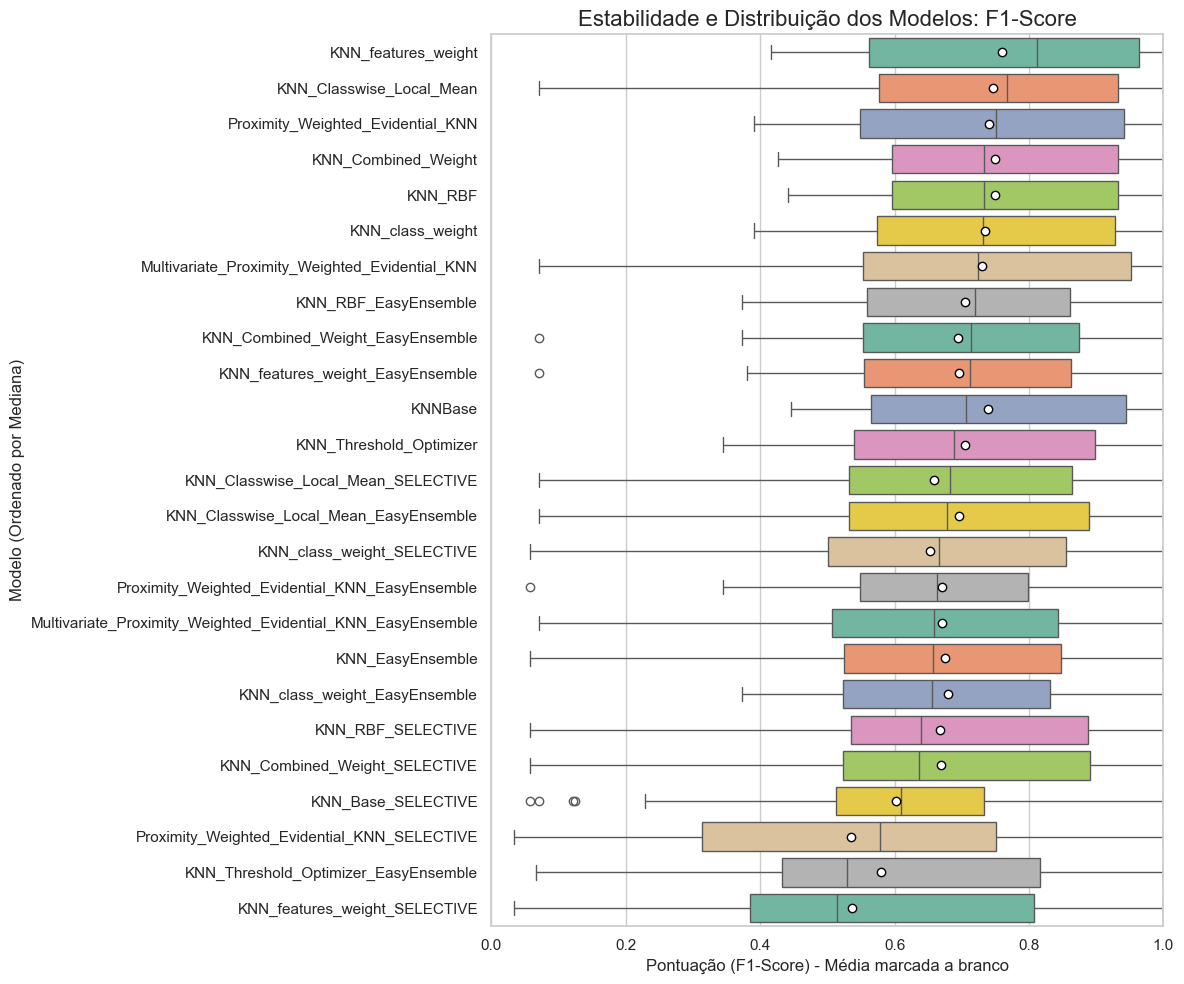

/var/folders/ws/v_d_g0rn7178ft7w39nl11m00000gn/T/ipykernel_61168/3991804583.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


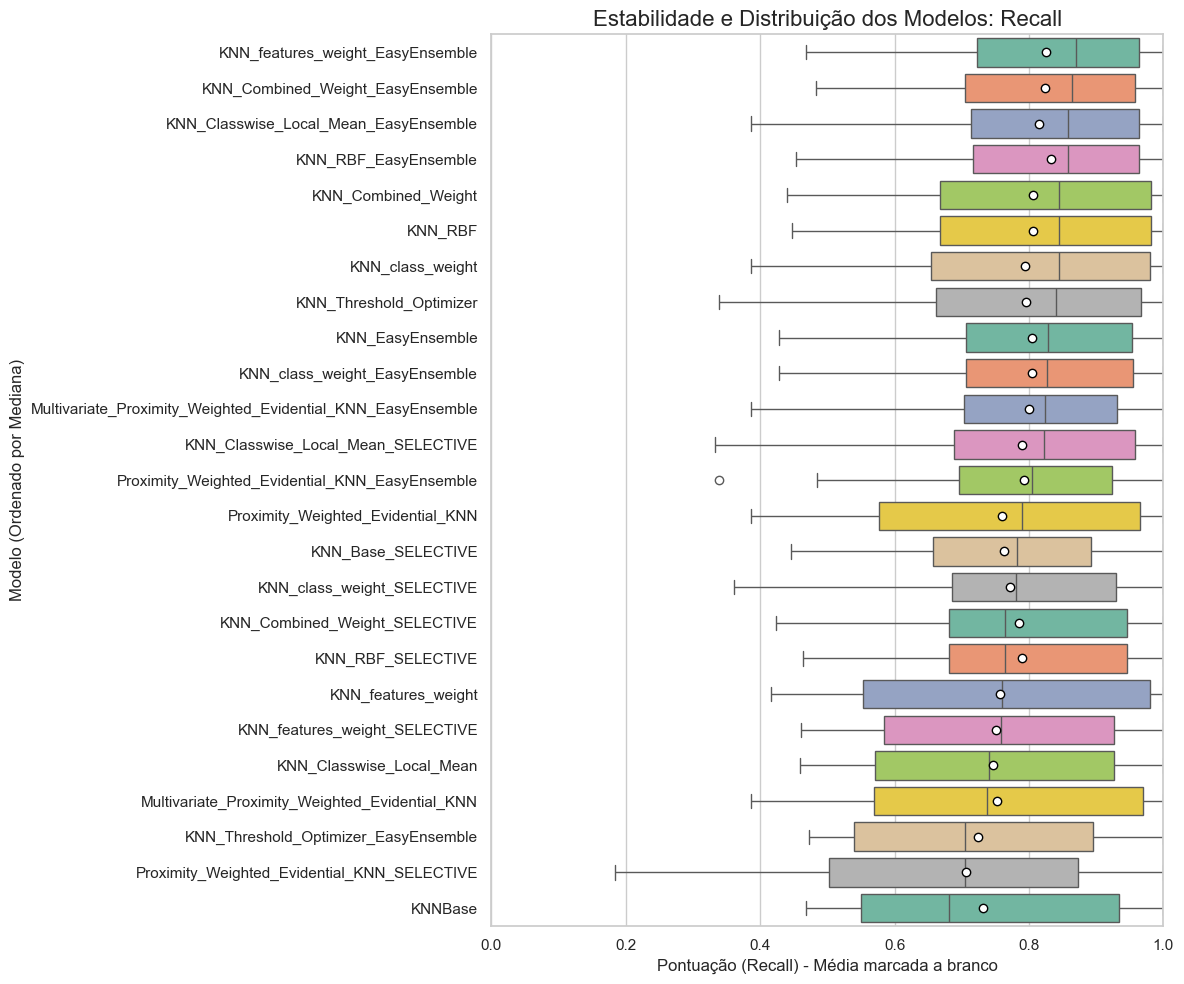

/var/folders/ws/v_d_g0rn7178ft7w39nl11m00000gn/T/ipykernel_61168/3991804583.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


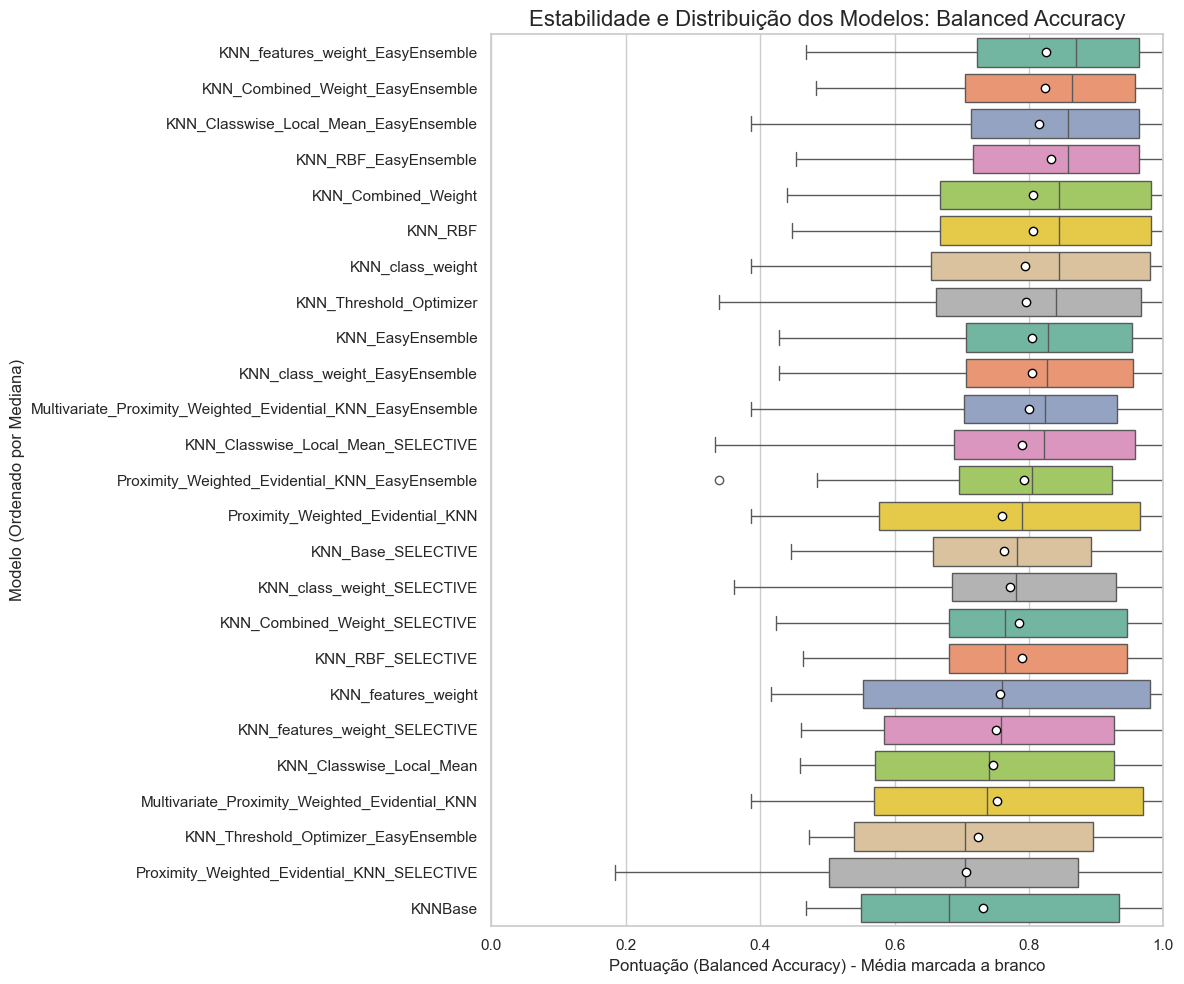

/var/folders/ws/v_d_g0rn7178ft7w39nl11m00000gn/T/ipykernel_61168/3991804583.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


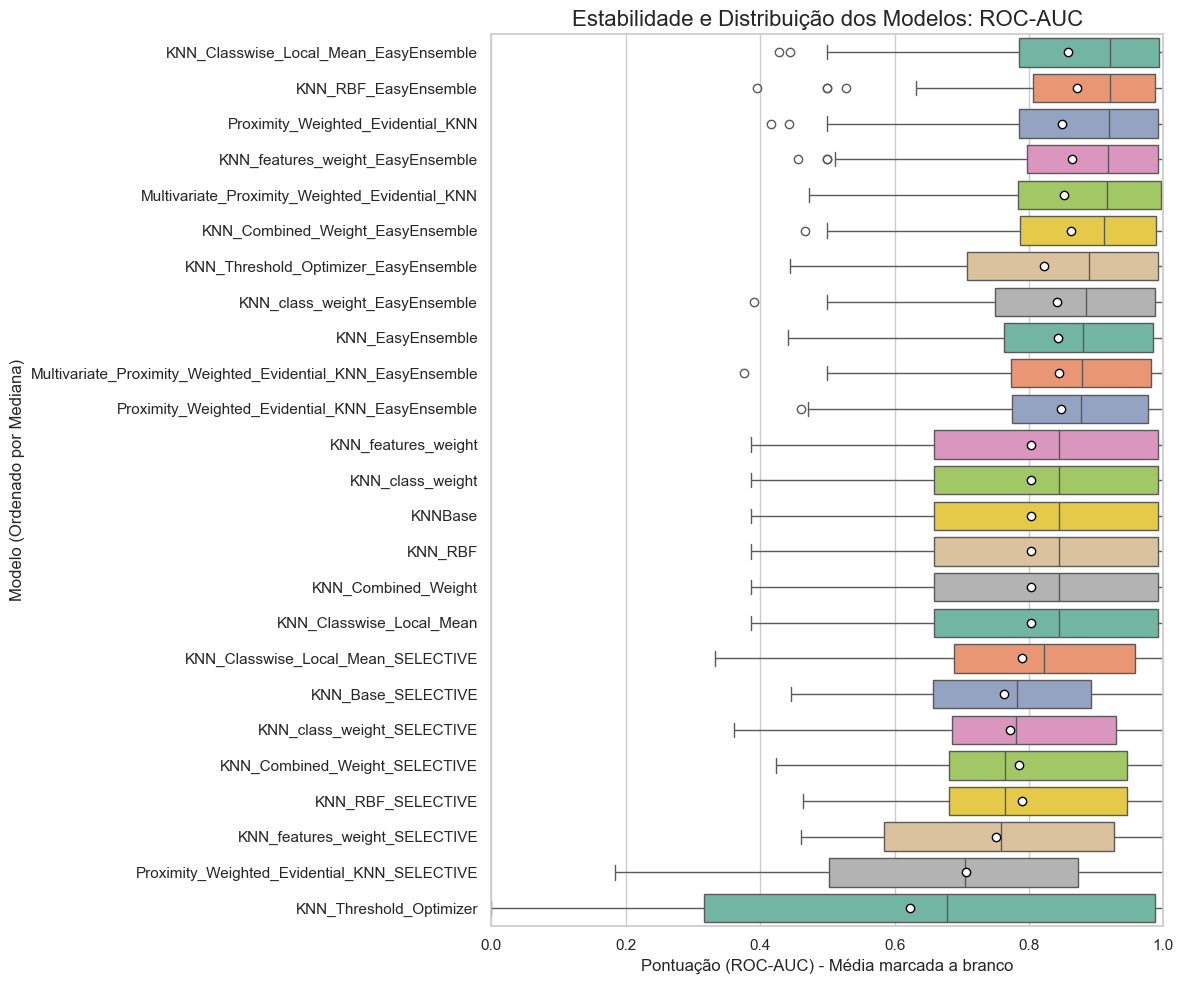

/var/folders/ws/v_d_g0rn7178ft7w39nl11m00000gn/T/ipykernel_61168/3991804583.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


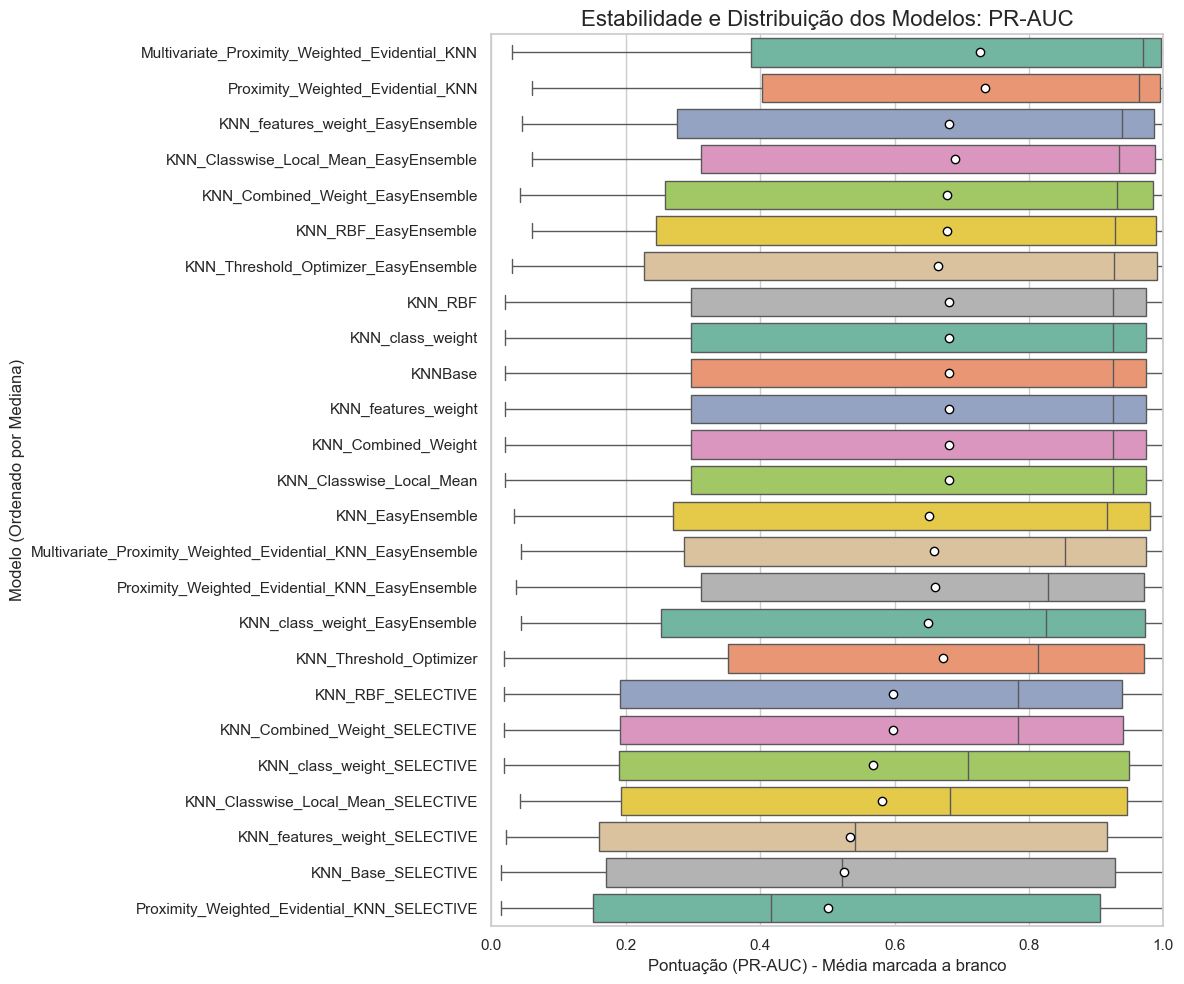

In [276]:
def plotar_distribuicao_modelos(df_resultados):
    metricas = ["F1-Score", "Recall", "Balanced Accuracy", "ROC-AUC", "PR-AUC"]
    sns.set_theme(style="whitegrid")
    
    paleta_clara = "Set2" 
    
    for metrica in metricas:
        if df_resultados[metrica].isna().all():
            print(f"Aviso: A métrica {metrica} só contém valores nulos e não será plotada.")
            continue

        num_modelos = len(df_resultados['Modelo'].unique())
        altura = max(6, num_modelos * 0.4)
        
        plt.figure(figsize=(12, altura))
        
        ordem = df_resultados.groupby('Modelo')[metrica].median().dropna().sort_values(ascending=False).index
        
        sns.boxplot(
            data=df_resultados,
            x=metrica,
            y="Modelo",
            order=ordem,
            palette=paleta_clara,
            showmeans=True, 
            meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black"}
        )
        
        plt.title(f"Estabilidade e Distribuição dos Modelos: {metrica}", fontsize=16)
        plt.xlabel(f"Pontuação ({metrica}) - Média marcada a branco")
        plt.ylabel("Modelo (Ordenado por Mediana)")
        plt.xlim(0, 1)
        
        plt.tight_layout()
        plt.show()

plotar_distribuicao_modelos(pd.DataFrame(resultados_lista))

<h1 style="text-align: center; color: #FFB6C1; font-size: 40px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
    ------- ANÁLISE DE RESULTADOS -------
</h1>

A conclusão mais evidente em métricas como o Recall e a Balanced Accuracy é o sucesso das variantes que utilizam o EasyEnsemble_Wrapper. Modelos como o KNN_features_weight_EasyEnsemble e o Multivariate_Proximity_Weighted_Evidential_KNN_EasyEnsemble dominam consistentemente o topo dos rankings, o que confirma que as suas respestivas estratégias são mais robustas para identificar a classe minoritária sem comprometer a visão global do problema.

No entanto, é também possível observar um compromisso visível no F1-Score. Enquanto os modelos base e as variantes do PeKNN apresentam medianas de F1-Score muito elevadas e caixas mais compactas, as versões que utilizam EasyEnsemble ou SELECTIVE mostram uma variabilidade maior. Isto sugere que, ao forçarmos o algoritmo a focar-se na classe minoritária, podemos introduzir um maior número de falsos positivos em determinados conjuntos de dados, o que torna a precisão — e, por consequência, o F1-Score — mais instável.

Quanto à arquitetura interna dos algoritmos, as variantes baseadas na Teoria das Evidências, nomeadamente o sPeKNN e o mPeKNN, provaram ser bases muito mais sofisticadas do que o KNN tradicional. Mesmo sem o auxílio de wrappers, estas variantes mantêm-se quase sempre na metade superior dos gráficos de desempenho, com um destaque especial na métrica ROC-AUC. Este desempenho sólido demonstra que a modelação da incerteza através de massas de ignorância e confiança estatística permite capturar a estrutura dos dados de forma muito mais eficaz do que a simples contagem de vizinhos por proximidade geométrica.

Por fim, a estratégia do Selective Wrapper apresenta um desempenho intermédio. Embora cumpra o seu papel de proteger a classe minoritária ao elevar o Recall para níveis aceitáveis, a sua performance em termos de separação (ROC-AUC) e equilíbrio (F1-Score) fica aquém do EasyEnsemble. Isto indica que a remoção definitiva de amostras da classe maioritária para equilibrar o treino pode resultar numa perda de informação valiosa, tornando a abordagem de comitê (Ensemble) uma solução mais segura e completa para este tipo de desafio académico.

<h1 style="text-align: center; color: #FFB6C1; font-size: 40px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
    ------- CONCLUSÃO -------
</h1>



A análise das diversas variantes do KNN implementadas neste trabalho demonstra que a eficácia deste algoritmo em problemas de class imbalance depende muito da transição de uma votação puramente numérica para uma abordagem baseada em relevância e evidência. Enquanto as versões baseadas em pesos de classes e atributos permitiram compensar a disparidade de frequências nos datasets, as variantes evidenciais (sPeKNN e mPeKNN) elevaram a robustez do modelo ao incorporar a incerteza estatística através da Teoria de Dempster-Shafer, revelando-se superiores na gestão de ruído e distribuições complexas.  

A utilização de wrappers, como o Selective Wrapper e o Easy Ensemble, confirmou que a otimização da performance não reside apenas no algoritmo em si, mas na inteligência aplicada à seleção e balanceamento dos dados de treino. Ao longo dos testes realizados, o foco em métricas como Balanced Accuracy e PR-AUC foi determinante para validar estas técnicas, comprovando que estas conseguem, de facto, capturar a capacidade de separação real do modelo onde a acurácia tradicional falharia. Em suma, o trabalho reforça que o KNN, quando devidamente adaptado por mecanismos de ponderação e estratégias de amostragem inteligente, mantém-se como uma ferramenta de classificação adequada aos desafios de dados desequilibrados.